# Post-processing: merge BinWaves + BMUS across all grids

This notebook merges per-grid **BinWaves + KMA-BMU SWAN** bulk hindcasts and builds
webpage GeoJSON statistics (same layout as `inputs/webpage_examples/`).

It replaces the ShoreShop `cropped_variables` merge in `postProcessing_all_grids.ipynb`.

## Pipeline (per grid)

Each `gridN` folder runs the KMA wind pipeline (`00_kma_wind_pipeline.ipynb`):

1. **WHACS seapoints** → PCA → MDA → **KMA** (250 clusters / BMUs)
2. **SWAN `CASES_ONLY_WIND`** — one folder per BMU (`000`…`249`) with `output.mat`
3. **BinWaves bulk** — ShoreShop `cropped_variables` (`hs_gridN_masked.nc`, partitions `phs0`, …)
4. **Hourly BMU assignment** — `outputs/KMA/nearest_centroids_idxs_kma_pcs.csv`
5. **Combine** — for each hour/site, merge KMA cluster wind-sea partition into BinWaves:
   - wind-sea `phs0/ptp0/dp0` from the active BMU's SWAN `output.mat`
   - total `hs/tp/dp/dm/tm02` = energy combination of partitions + BinWaves swell
6. **Output** — `gridN/outputs/BinWaves_BMUS/*_gridN_BinWaves_BMUS.nc`

### Grids

| Grid | Domain | Sites (approx.) | Example file |
|------|--------|-----------------|--------------|
| grid1 | SC / GA coast | 845 | `grid1/outputs/BinWaves_BMUS/hs_grid1_BinWaves_BMUS.nc` |
| grid2 | Mid-Atlantic | 1105 | `grid2/outputs/BinWaves_BMUS/hs_grid2_BinWaves_BMUS.nc` |
| grid3 | VA / MD | 1386 | `grid3/outputs/BinWaves_BMUS/hs_grid3_BinWaves_BMUS.nc` |
| grid4 | North Carolina | 848 | `grid4/outputs/BinWaves_BMUS/hs_grid4_BinWaves_BMUS.nc` |

Build per grid if missing: `bash gridN/utils/build_kma_merged_grids.sh`

### This notebook

- **Merge** — smooth buffer blend (`merge_all_binwaves_bmus_smooth`) → `outputs/merged_grids_binwaves_bmus/{var}_merged_all.nc`
- **Webpage** — `webpage_binwaves_bmus/wave_statistics_{all,hs,dp}.geojson`

In [2]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel")
GRID_NAMES = ["grid1", "grid2", "grid3", "grid4"]
MERGED_DIR = PROJECT_ROOT / "outputs/merged_grids_binwaves_bmus"
WEBPAGE_DIR = PROJECT_ROOT / "webpage_binwaves_bmus"
WEBPAGE_EXAMPLES = PROJECT_ROOT / "inputs/webpage_examples"

SMOOTH_STEEPNESS = 2.0       # lower = wider / softer transition (default sequential merge uses 10)
BLEND_BUFFER_KM = 30.0       # km outside polygon where the other grid still contributes
TOLERANCE_DEG = 0.001
SKIP_EXISTING = True  # set False to rebuild merged files

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils import postprocessing_binwaves_bmus as pb

MERGED_DIR.mkdir(parents=True, exist_ok=True)
WEBPAGE_DIR.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_ROOT)
print("Merged output:", MERGED_DIR)
print("Webpage output:", WEBPAGE_DIR)

Project: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel
Merged output: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus
Webpage output: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/webpage_binwaves_bmus


## 2. Audit per-grid `BinWaves_BMUS` inputs

Only variables that exist under at least one grid are discovered. Each variable is merged
using whichever grids have that file (missing grids are skipped with a warning).

In [11]:
audit = pb.audit_grid_binwaves_bmus(PROJECT_ROOT, GRID_NAMES)
pivot = audit.pivot(index="variable", columns="grid", values="exists")
display(pivot)

VARIABLES_TO_PROCESS = pb.discover_binwaves_bmus_variables(PROJECT_ROOT, GRID_NAMES)
print("Variables to merge:", VARIABLES_TO_PROCESS)

missing = audit[~audit["exists"]]
if missing.empty:
    print("All grid/variable pairs present.")
else:
    print(f"Missing {len(missing)} file(s):")
    display(missing[["grid", "variable", "path"]])

grid,grid1,grid2,grid3,grid4
variable,,,,
dm,True,True,True,True
dp,True,True,True,True
dp0,True,True,True,True
hs,True,True,True,True
phs0,True,True,True,True
ptp0,True,True,True,True
tm02,True,True,True,True
tp,True,True,True,True


Variables to merge: ['hs', 'tp', 'dm', 'dp', 'tm02', 'phs0', 'ptp0', 'dp0']
All grid/variable pairs present.


## 3. Merge all grids (BinWaves + BMUS)

Smooth buffer blend across **all grids at once** (`merge_all_binwaves_bmus_smooth`):

- **Direction vars** (`dp`, `dm`, `dp0`) — circular weighted mean (sin/cos)
- **Scalar vars** (`hs`, `tp`, `tm02`, …) — linear weighted mean
- **Soft sigmoid** — lower `SMOOTH_STEEPNESS` widens the in-overlap transition
- **Buffer corridor** — points up to `BLEND_BUFFER_KM` outside a polygon still pull from the neighbour grid

Input pattern: `gridN/outputs/BinWaves_BMUS/{var}_gridN_BinWaves_BMUS.nc`

Output: `outputs/merged_grids_binwaves_bmus/{var}_merged_all.nc`

> Long-running step — prefer running in a terminal or batch session.

In [ ]:
merged_paths = pb.merge_all_binwaves_bmus_smooth(
    project_root=PROJECT_ROOT,
    output_dir=MERGED_DIR,
    grid_names=GRID_NAMES,
    variables=VARIABLES_TO_PROCESS,
    steepness=SMOOTH_STEEPNESS,
    blend_buffer_km=BLEND_BUFFER_KM,
    tolerance_deg=TOLERANCE_DEG,
    skip_existing=SKIP_EXISTING,
)

print("Merged files:")
for var, path in merged_paths.items():
    size_mb = path.stat().st_size / 1e6 if path.is_file() else 0
    blend = "circular" if var in pb.CIRCULAR_BLEND_VARS else "linear"
    print(f"  {var:8s} {path.name}  ({size_mb:.1f} MB, {blend} blend)")

In [ ]:
# 3b) Smooth merge partition variables (1-3) from ShoreShop cropped_variables
from pathlib import Path
import re
import importlib

importlib.reload(pb)  # pick up the updated NetCDF writer

SHORESHOP_CROPPED_VARS_DIR = Path("/lustre/geocean/WORK/users/montanoj/personal/ShoreShop2026/outputs/cropped_variables")
MERGED_PARTITIONS_DIR = Path("/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/merged_binwaves_bmus")
MERGED_PARTITIONS_DIR.mkdir(parents=True, exist_ok=True)

partition_vars = [
    "phs1", "phs2", "phs3",
    "ptp1", "ptp2", "ptp3",
    "dp1", "dp2", "dp3",
    "spr1", "spr2", "spr3",
]

merged_partition_paths = {}
for var_name in partition_vars:
    final_path = MERGED_PARTITIONS_DIR / f"{var_name}_merged_all.nc"
    if SKIP_EXISTING and final_path.is_file():
        print(f"Skip {var_name}: {final_path.name} exists")
        merged_partition_paths[var_name] = final_path
        continue

    grid_files = sorted(
        SHORESHOP_CROPPED_VARS_DIR.glob(f"{var_name}_grid*_masked.nc"),
        key=lambda p: int(re.search(r"_grid(\d+)_", p.name).group(1)),
    )

    if not grid_files:
        print(f"No cropped files found for {var_name}; skipping")
        continue

    base_var = re.sub(r"\d+$", "", var_name)  # dp1 -> dp (circular blend)
    blend_kind = "circular" if base_var in pb.CIRCULAR_BLEND_VARS else "linear"
    print(f"Smooth merge {var_name} ({blend_kind}) from {len(grid_files)} grid(s)...")

    pb.merge_grids_smooth(
        grid_files=grid_files,
        var_name=var_name,
        steepness=SMOOTH_STEEPNESS,
        blend_buffer_km=BLEND_BUFFER_KM,
        tolerance_deg=TOLERANCE_DEG,
        output_file=final_path,
    )
    merged_partition_paths[var_name] = final_path

print("Merged partition files:")
for var, path in merged_partition_paths.items():
    size_mb = path.stat().st_size / 1e6 if path.is_file() else 0
    blend = "circular" if re.sub(r"\d+$", "", var) in pb.CIRCULAR_BLEND_VARS else "linear"
    print(f"  {var:8s} {path.name}  ({size_mb:.1f} MB, {blend} blend)")

Smooth merge phs1 (linear) from 4 grid(s)...


/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_from_path(grid_file))
/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_from_path(grid_file))
/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_fr

  hs: smooth merge:   0%|          | 0/3151 [00:00<?, ?it/s]

Saved /nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/merged_binwaves_bmus/phs1_merged_all.nc
Smooth merge phs2 (linear) from 4 grid(s)...


/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_from_path(grid_file))
/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_from_path(grid_file))
/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_fr

...

/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_from_path(grid_file))
/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_from_path(grid_file))
/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_fr

  hs: smooth merge:   0%|          | 0/3151 [00:00<?, ?it/s]

Saved /nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/merged_binwaves_bmus/phs3_merged_all.nc
Smooth merge ptp1 (linear) from 4 grid(s)...


/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_from_path(grid_file))
/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_from_path(grid_file))
/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/utils/postprocessing_binwaves_bmus.py:627: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  grid_names.append(grid_name_fr

  tp: smooth merge:   0%|          | 0/3151 [00:00<?, ?it/s]

## 4. Generate webpage GeoJSON

Writes three files into `webpage_binwaves_bmus/` (same property layout as `inputs/webpage_examples/`):

- `wave_statistics_all.geojson` — Hs/Tp/Tm02/Dp/Dm means, Hs max & 95th percentile
- `wave_statistics_hs.geojson` — Hs monthly & seasonal climatology
- `wave_statistics_dp.geojson` — Dp monthly & seasonal climatology (circular mean)

Requires merged files: `hs`, `tp`, `tm02`, `dp`, `dm`.

In [3]:
import importlib
from utils import postprocessing_binwaves_bmus as pb
importlib.reload(pb)
geojson_paths = pb.generate_webpage_geojson(
    merged_dir=MERGED_DIR,
    output_dir=WEBPAGE_DIR,
)

for key, path in geojson_paths.items():
    size_mb = path.stat().st_size / 1e6
    print(f"{key}: {path} ({size_mb:.1f} MB)")

print("\nReference examples:", list(WEBPAGE_EXAMPLES.glob("*.geojson")))

/nfs/home/geocean/montanoj/miniforge3/envs/bluemath-dev/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


wave_statistics_all:   0%|          | 0/3151 [00:00<?, ?it/s]

wave_statistics_hs:   0%|          | 0/3151 [00:00<?, ?it/s]

wave_statistics_dp:   0%|          | 0/3151 [00:00<?, ?it/s]

all: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/webpage_binwaves_bmus/wave_statistics_all.geojson (1.9 MB)
hs: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/webpage_binwaves_bmus/wave_statistics_hs.geojson (3.0 MB)
dp: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/webpage_binwaves_bmus/wave_statistics_dp.geojson (3.0 MB)

Reference examples: [PosixPath('/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/inputs/webpage_examples/wave_statistics_hs.geojson'), PosixPath('/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/inputs/webpage_examples/wave_statistics_dp.geojson'), PosixPath('/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/inputs/webpage_examples/wave_statistics_all.geojson')]


## 5. Quick check: Dp transition at grid interfaces

After the smooth merge above, inspect mean Dp near the grid3 ↔ grid4 overlap. If the seam is still visible,
try lowering `SMOOTH_STEEPNESS` (e.g. 1.0) or raising `BLEND_BUFFER_KM` (e.g. 40) and re-run section 3 with `SKIP_EXISTING = False`.

Input files:
  /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/grid3/outputs/BinWaves_BMUS/dp_grid3_BinWaves_BMUS.nc (1285.2 MB)
  /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/grid4/outputs/BinWaves_BMUS/dp_grid4_BinWaves_BMUS.nc (790.1 MB)


/tmp/ipykernel_3305325/2130210016.py:95: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(grid_file, chunks={"time": 10_000})
/tmp/ipykernel_3305325/2130210016.py:95: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 10000. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(grid_file, chunks={"time": 10_000})


  dp: smooth direction merge:   0%|          | 0/1578 [00:00<?, ?it/s]

Saved /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus/dp_merged_grid3_grid4_smooth.nc


/tmp/ipykernel_3305325/2130210016.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


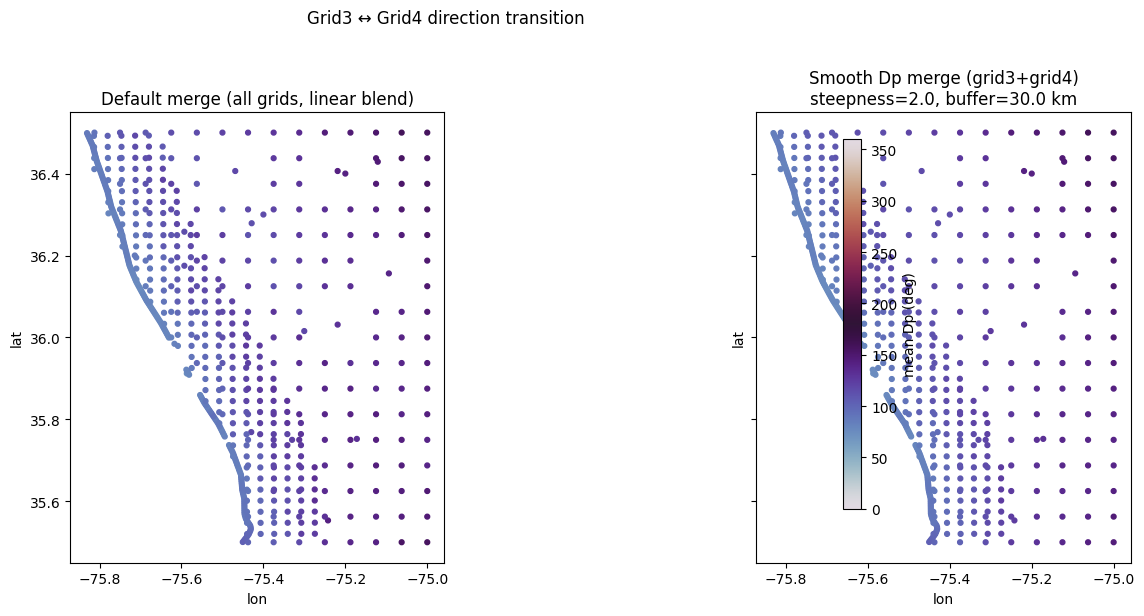


Smooth merge: 1578 sites -> /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus/dp_merged_grid3_grid4_smooth.nc
If the seam is still visible, try lowering STEEPNESS (e.g. 1.0) or raising BLEND_BUFFER_KM (e.g. 40).


In [4]:
import matplotlib.pyplot as plt
import xarray as xr

DP_MERGED = MERGED_DIR / "dp_merged_all.nc"
if not DP_MERGED.is_file():
    raise FileNotFoundError(f"Run section 3 first: {DP_MERGED}")

with xr.open_dataset(DP_MERGED) as ds:
    lon = ds.lon.values
    lat = ds.lat.values
    dp_mean = ds.dp.mean("time", skipna=True).values

# focus on the grid3/grid4 interface (rough bbox from overlap region)
lon_min, lon_max = -76.2, -75.0
lat_min, lat_max = 35.5, 36.5
mask = (lon >= lon_min) & (lon <= lon_max) & (lat >= lat_min) & (lat <= lat_max)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(lon[mask], lat[mask], c=dp_mean[mask], s=12, cmap="twilight", vmin=0, vmax=360)
ax.set_title(
    f"Smooth Dp merge (all grids)\nsteepness={SMOOTH_STEEPNESS}, buffer={BLEND_BUFFER_KM} km"
)
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_aspect("equal")
fig.colorbar(sc, ax=ax, label="mean Dp (deg)", shrink=0.8)
fig.suptitle("Grid3 ↔ Grid4 direction transition", y=1.02)
plt.tight_layout()
plt.show()

print(f"Smooth merge: {len(lon)} sites -> {DP_MERGED}")

## 6. Buoy validation (merged all-grids BinWaves + BMUS)

Bulk hindcast from `MERGED_DIR` (`hs/tp/dp/dm_merged_all.nc`). Run the setup cell below, then the validation cell.

In [ ]:
# Setup for buoy validation — bulk hindcast from merged all-grids BinWaves+BMUS
_GRID4 = PROJECT_ROOT / "grid4"
if str(_GRID4) not in sys.path:
    sys.path.insert(0, str(_GRID4))

_HIST_KW = dict(
    historical_folder=str(MERGED_DIR),
    partitions_dataset="merged_grids",
    project_root=PROJECT_ROOT,
)

print("Hindcast folder:", MERGED_DIR)
print("gcm_comparison from:", _GRID4 / "utils/gcm_comparison.py")

Hindcast folder: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus
gcm_comparison from: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/grid4/utils/gcm_comparison.py


In [ ]:
# Buoy vs hindcast bulk validation: scatter, CSV, and Hs/Tp/Dp time series
import importlib
import sys
from pathlib import Path

# Cell 1 imports project-root `utils`; gcm_comparison lives under grid4/utils.
# Cwd (PROJECT_ROOT) and project-root on sys.path shadow grid4/utils — drop them briefly.
_saved_path = sys.path.copy()
_saved_utils = sys.modules.pop("utils", None)
_saved_submods = {
    k: sys.modules.pop(k) for k in list(sys.modules) if k.startswith("utils.")
}
sys.path = [
    p
    for p in sys.path
    if p != "" and Path(p).resolve() != PROJECT_ROOT.resolve()
]
if str(_GRID4) not in sys.path:
    sys.path.insert(0, str(_GRID4))

import utils.gcm_comparison as gc
importlib.reload(gc)

sys.path = _saved_path
if _saved_utils is not None:
    sys.modules["utils"] = _saved_utils
sys.modules.update(_saved_submods)

buoys = {
    'SSBN7': (-78.484, 33.838),
    '41119': (-78.483, 33.842),
    'OCPN7': (-78.147, 33.911),
    '41108': (-78.016, 33.721),
    '41013': (-77.764, 33.441),
    '41110': (-77.715, 34.142),
    '41109': (-77.300, 34.484),
    '41035': (-77.281, 34.476),
    '41036': (-76.949, 34.207),
    '41159': (-76.944, 34.211),
    '41007': (-76.5, 34.2),

    'jprn7': (-75.5870, 35.9120),
    '41017': (-75.1000, 35.4000),
    '41015': (-75.3000, 35.4000),
    '41120': (-75.2580, 35.2580),
    'dsln7': (-75.2970, 35.1530),
    '41025': (-75.4540, 35.0100),
    '44095': (-75.3300, 35.7500),
    '44086': (-75.3300, 35.7500),

    '44006': (-75.4000, 36.3000),
    '44079': (-75.5930, 36.1750),
    '44056': (-75.7140, 36.2000),
    '44100': (-75.5930, 36.2580),
    '44019': (-75.2000, 36.4000),
    '44014': (-74.837, 36.603),
    '44088': (-74.839, 36.612),
}

BUOY_VALIDATION_OUT = PROJECT_ROOT / "outputs/Figures/buoy_validation_binwaves_bmus"
BUOY_VALIDATION_CSV = BUOY_VALIDATION_OUT

gc.plot_buoy_bulk_validation_scatter(
    list(buoys.keys()),
    buoys=buoys,
    aggregation="hourly",
    use_buoy_time_range=True,
    output_folder=BUOY_VALIDATION_OUT,
    csv_output_folder=BUOY_VALIDATION_CSV,
    save_timeseries=True,
    save=True,
    show=False,
    **_HIST_KW,
)


Buoy bulk validation scatter — historical_folder: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | model label: BinWaves + KMA clusters
Saved: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/Figures/buoy_validation_binwaves_bmus/buoy_validation_SSBN7.csv
Saved: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/Figures/buoy_validation_binwaves_bmus/validation_timeseries_SSBN7.png
Saved: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/Figures/buoy_validation_binwaves_bmus/validation_scatter_SSBN7.png
Saved: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/Figures/buoy_validation_binwaves_bmus/buoy_validation_41119.csv
Saved: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/Figures/buoy_validation_binwaves_bmus/validation_timeseries_41119.png
Saved: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/Figures/buoy_validation_binwave

[BuoyHistoricalMatch(buoy_id='SSBN7', buoy_lat=33.838, buoy_lon=-78.484, coordinate=(33.8380012512207, -78.48400115966797), distance_km=0.00017558170735819788, match_source='historical_grid', site_index=5, time_start=None, time_end=None, shore_normal_deg=None),
 BuoyHistoricalMatch(buoy_id='41119', buoy_lat=33.842, buoy_lon=-78.483, coordinate=(33.84199905395508, -78.48300170898438), distance_km=0.00018967837551140716, match_source='historical_grid', site_index=6, time_start=None, time_end=None, shore_normal_deg=None),
 BuoyHistoricalMatch(buoy_id='OCPN7', buoy_lat=33.911, buoy_lon=-78.147, coordinate=(33.9109992980957, -78.14700317382812), distance_km=0.0003031056528895374, match_source='historical_grid', site_index=7, time_start=None, time_end=None, shore_normal_deg=None),
 BuoyHistoricalMatch(buoy_id='41108', buoy_lat=33.721, buoy_lon=-78.016, coordinate=(33.72100067138672, -78.01599884033203), distance_km=0.00013067773310131131, match_source='historical_grid', site_index=8, time_st